 # Notebook 05: Spatchcocking — 3D to 2D projection

 **Paper section:** Methods — Spatchcocking transformation
 **Paper figures:** Fig. 2 (coordinate system), Figs. 3–6 (heatmaps)

 This script flattens the 3D basal surface mesh into a 2D map using the
 spatchcocking transformation, combining all scalar measurements from
 notebooks 02–04 into a single CSV file.

 **Pipeline:**
 1. Load the basal mesh and transfer all scalar fields onto it
    (curvature, thickness, pHH3 density) from the `.npy` files
 2. Load the pre-computed medial axis and endpoints
 3. `getPlanes` — slice the tube into cross-sectional planes
 4. `getDeformedmesh2` — cylindrical unwrapping via thin-plate spline
 5. `get_flatdata2` — extract 2D coordinates (arc length, azimuthal angle)
 6. `normalize_values2` — normalise to s ∈ [0,1] rostrocaudal,
    θ ∈ [−180°, 180°] dorsoventral
 7. Export to CSV: one row per mesh vertex

 **Output:** `{timestamp}-spatchcocked.csv` with columns:
 radius, norm_height, angle_degrees, Gauss_Curvature, Mean_Curvature,
 K1, K2, thickness, phh3

In [ ]:
from vedo import settings
settings.default_backend = "vtk"

from spatchcocking import *
import numpy as np
import pandas as pd
import os
import re
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.interpolate import griddata

 ## Parameters

In [ ]:
# --- Input files ---
mesh_path       = "../data/example/basal.ply"
axis_path       = "../data/example/2025-10-22-12-30-axis.npy"
endpts_path     = "../data/example/2025-10-22-12-30-endpts.npy"
curvature_path  = "../data/example/basal-curvatures.npy"
thickness_path  = "../data/example/basal-thickness.npy"
phh3_path       = "../data/example/basal-phh3density.npy"

# --- Spatchcocking ---
dists_threshold = 640    # max vertex-to-plane distance; increase if vertices are clipped
shift_deg       = -90    # rotation to align dorsal midline to angle = 0°

# --- Output ---
timestamp = re.search(r"\d{4}-\d{2}-\d{2}-\d{2}-\d{2}", axis_path).group()
csv_file  = f"../data/example/{timestamp}-spatchcocked.csv"

# --- Plot ---
TARGET_PROPERTY = "Gauss_Curvature"   # one of: Gauss_Curvature, Mean_Curvature,
                                       #         K1, K2, thickness, phh3

 ## Load mesh and transfer all scalar fields

 Each `.npy` file is loaded as a point cloud, and its scalar data is
 spatially interpolated onto the basal mesh vertices using the 5 nearest
 neighbours (`interpolate_data_from`).

In [ ]:
si = Mesh(mesh_path)

# --- Curvature (N,7): X Y Z K H K1 K2 ---
curv = np.load(curvature_path)
pc_curv = Points(curv[:, :3])
pc_curv.pointdata["Gauss_Curvature"] = curv[:, 3]
pc_curv.pointdata["Mean_Curvature"]  = curv[:, 4]
pc_curv.pointdata["K1"]              = curv[:, 5]
pc_curv.pointdata["K2"]              = curv[:, 6]
si.interpolate_data_from(pc_curv, n=5)

# --- Thickness (N,4): X Y Z thickness ---
thick = np.load(thickness_path)
pc_thick = Points(thick[:, :3])
pc_thick.pointdata["thickness"] = thick[:, 3]
si.interpolate_data_from(pc_thick, n=5)

# --- pHH3 density (N,4): X Y Z density ---
phh3 = np.load(phh3_path)
pc_phh3 = Points(phh3[:, :3])
pc_phh3.pointdata["phh3"] = phh3[:, 3]
si.interpolate_data_from(pc_phh3, n=5)

print("Scalar fields on mesh:", list(si.pointdata.keys()))

Scalar fields on mesh: ['phh3', 'thickness', 'Gauss_Curvature', 'Mean_Curvature', 'K1', 'K2']


 ## Load (or interactively select) medial axis and endpoints

 If the `.npy` files already exist they are loaded directly.
 If not, an interactive vedo window opens for manual selection:
 - **Endpoints**: click the two ends of the tube on the mesh
 - **Axis**: computed automatically from the endpoints via `getAxis`

In [ ]:
# --- Endpoints ---
if os.path.exists(endpts_path):
    print(f"Loading endpoints: {endpts_path}")
    endpts = np.load(endpts_path)
else:
    # Opens interactive window — click the two tube endpoints, then close
    endpts = selectPointsonMesh(si, timestamp)   # saves {timestamp}-endpts.npy

# --- Medial axis ---
if os.path.exists(axis_path):
    print(f"Loading axis: {axis_path}")
    axispts = np.load(axis_path)
else:
    # Fits a smooth 1D curve through the tube centroids between the endpoints
    axispts = getAxis(si, endpts, timestamp, num_points=25, N=10, check=True)   # saves {timestamp}-axis.npy

print(f"Axis: {len(axispts)} control points")
print(f"Endpoints: {endpts.shape}")

Loading endpoints: ../data/example/2025-10-22-12-30-endpts.npy
Loading axis: ../data/example/2025-10-22-12-30-axis.npy
Axis: 25 control points
Endpoints: (12, 3)


 ## Spatchcocking

 Check if the CSV already exists before running (the deformation step can
 be slow on large meshes).

In [ ]:
run_computation = True

if os.path.exists(csv_file):
    answer = input(f"'{csv_file}' already exists. Rerun spatchcocking? [y/N]: ")
    run_computation = answer.strip().lower() == "y"

if run_computation:
    # Step 1: build cross-sectional planes along the medial axis
    axis_info = getPlanes(si, axispts, endpts, check=False)

    # Step 2: cylindrical unwrapping via thin-plate spline
    # dists_threshold clips vertices too far from any plane (artefact prevention)
    deformed_mesh = getDeformedmesh2(si, axis_info,
                                     namefile=timestamp,
                                     skip_index=[],
                                     dists_threshold=dists_threshold,
                                     check=False)
    print("Deformed mesh ready.")

    # Step 3: extract 2D coordinates from the unwrapped mesh
    radius, angle, height, dmesh2 = get_flatdata2(deformed_mesh)

    # Step 4: normalise arc length to [0,1] and convert angle to degrees
    # shift_deg rotates the angular origin to align dorsal to 0°
    norm_height, angle_degrees = normalize_values2(height, angle, shift_deg=shift_deg)

    # Step 5: collect all fields into a DataFrame and save
    df = pd.DataFrame({
        "radius":          radius,
        "norm_height":     norm_height,
        "angle_degrees":   angle_degrees,
        "Gauss_Curvature": dmesh2.pointdata["Gauss_Curvature"],
        "Mean_Curvature":  dmesh2.pointdata["Mean_Curvature"],
        "K1":              dmesh2.pointdata["K1"],
        "K2":              dmesh2.pointdata["K2"],
        "thickness":       dmesh2.pointdata["thickness"],
        "phh3":            dmesh2.pointdata["phh3"],
    })

    df.to_csv(csv_file, index=False)
    print(f"Saved: {csv_file}  ({len(df)} rows, {len(df.columns)} columns)")
    print(f"Columns: {list(df.columns)}")

else:
    df = pd.read_csv(csv_file)
    print(f"Loaded: {csv_file}  ({len(df)} rows)")

vedo.mesh.core.Mesh
name          : Mesh
file name     : ../data/example/basal.ply
color         : lightblue, rgb=(0.678, 0.847, 0.902), alpha=1.0
elements      : vertices=1,002 polygons=2,000 lines=0
position      : (0, 0, 0)
scaling       : (1.00000, 1.00000, 1.00000)
size          : average=1088.90, diagonal=4815.05
center of mass: (1139.23, 1849.47, 3484.28)
bounds        : x=(136, 1.91e+3), y=(646, 3.34e+3), z=(1.35e+3, 4.92e+3)
pointdata *   : "phh3" (float32), dim=1, range=(1.69, 78.0)
pointdata     : "thickness" (float64), dim=1, range=(1.19, 131)
pointdata     : "Gauss_Curvature" (float64), dim=1, range=(-3.32e-5, 2.78e-5)
pointdata     : "Mean_Curvature" (float64), dim=1, range=(-3.42e-3, 6.82e-3)
pointdata     : "K1" (float64), dim=1, range=(1.99e-4, 0.0138)
pointdata     : "K2" (float64), dim=1, range=(-9.99e-3, 4.20e-3)
metadata      : "decimate_actual_fraction" = [0.2667378]
i am warpping now --
i am down warpping --
vedo.mesh.core.Mesh
name          : Mesh
file name     

 ## 2D heatmap

 Interpolate the scalar field onto a regular grid and display as a
 dorsoventral (x) × rostrocaudal (y) heatmap.

In [ ]:
def getTightercmap(values, sigma=3):
    """Return colour range clipped at median ± sigma × std."""
    return (np.median(values) - sigma * np.std(values),
            np.median(values) + sigma * np.std(values))

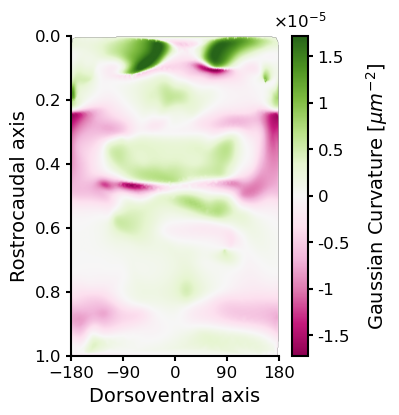

In [ ]:
# Property metadata: (axis label, colormap, symmetric range?)
property_map = {
    "Gauss_Curvature": (r"Gaussian Curvature [$\mu m^{-2}$]", "PiYG",      True),
    "Mean_Curvature":  (r"Mean Curvature [$\mu m^{-1}$]",     "PiYG",      True),
    "K1":              (r"Max principal k1 [$\mu m^{-1}$]",   "Spectral_r", True),
    "K2":              (r"Min principal k2 [$\mu m^{-1}$]",   "Spectral_r", True),
    "thickness":       (r"Thickness [$\mu m$]",                "GnBu",      False),
    "phh3":            (r"Local pHH3+ cell count",             "viridis",   False),
}

label, cmap_name, is_curv = property_map[TARGET_PROPERTY]

y_coord = 1 - df["norm_height"]   # rostrocaudal (flip so rostral = top)
x_coord = df["angle_degrees"]     # dorsoventral
z       = df[TARGET_PROPERTY]

# Normalise coordinates to [0,1] for griddata interpolation
y_norm = (y_coord - y_coord.min()) / (y_coord.max() - y_coord.min())
x_norm = (x_coord - x_coord.min()) / (x_coord.max() - x_coord.min())

grid_size = 500
xi, yi = np.meshgrid(np.linspace(0, 1, grid_size), np.linspace(0, 1, grid_size))
zi = griddata((x_norm, y_norm), z, (xi, yi), method="linear")

# Colour limits
vmin, vmax = getTightercmap(z, sigma=3)
if is_curv:
    vlim = max(abs(vmin), abs(vmax))
    vmin, vmax = -vlim, vlim
else:
    vmin = 0

# Plot
line_width = 1.5
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "xtick.major.width": line_width,
    "ytick.major.width": line_width,
    "axes.linewidth": line_width,
})

fig = plt.figure(figsize=(4, 4), dpi=100)
ax  = fig.add_axes([0.15, 0.1, 0.65, 0.8])

im = ax.imshow(zi,
               extent=[x_coord.min(), x_coord.max(),
                       y_coord.min(), y_coord.max()],
               origin="lower", aspect="auto",
               cmap=cmap_name, vmin=vmin, vmax=vmax)

ax.invert_yaxis()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xticks([-180, -90, 0, 90, 180])
ax.set_xlabel("Dorsoventral axis")
ax.set_ylabel("Rostrocaudal axis")

cbar = plt.colorbar(im, ax=ax, orientation="vertical", pad=0.05)

# Scientific notation for small curvature values
if is_curv or z.abs().max() < 0.1:
    exp = int(np.floor(np.log10(abs(vmax))))
    mult = 10 ** exp
    cbar.ax.yaxis.set_major_formatter(
        ticker.FuncFormatter(lambda val, pos, m=mult: f"{val/m:g}")
    )
    cbar.ax.text(0.5, 1.02, f"$\\times 10^{{{exp}}}$",
                 transform=cbar.ax.transAxes, ha="center", va="bottom")

cbar.set_label(label, labelpad=10)
plt.show()